<a href="https://colab.research.google.com/github/aamna18/grid-vision-wordsearch/blob/main/wordsearch_solver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── CELL 1 · Install dependencies ────────────────────────────────────────────
!apt-get update -y -q
!apt-get install -y -q poppler-utils libgl1
!pip install -q pdf2image opencv-python-headless pillow matplotlib easyocr

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,990 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,292 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:14 ht

In [2]:
# ── CELL 2 · Imports ─────────────────────────────────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import hsv_to_rgb
from pdf2image import convert_from_path
from PIL import Image
import easyocr

All imports OK


In [3]:
# ── CELL 3 · Configuration ────────────────────────────────────────────────────
FILE_PATH = '/content/puzzle2.pdf'

WORDS = [
    'THERIZINOSAURUS', 'RAJASAURUS',    'APATOSAURUS',
    'EUOPLOCEPHALUS',  'CAMARASAURUS',  'ERKETU',       'ELAPHROSAURUS',
    'DICRAEOSAURUS',   'METRIACANTHOSAURUS', 'DRYOSAURUS',
    'LEAELLYNASAURA',  'GOBISAURUS',    'CARNOTAURUS',  'FUKUIRAPTOR',
    'ALBERTOSAURUS',   'HYPSILOPHODON', 'EUROPASAURUS',
    'PTERANODON',      'DEINOCHEIRUS',  'ARGENTINOSAURUS', 'STYRACOSAURUS',
    'ALLOSAURUS',      'PLATEOSAURUS',  'CERATOSAURUS', 'ANKYLOSAURUS',
    'GARGOYLEOSAURUS', 'LILIENSTERNUS', 'COELOPHYSIS',  'EDMONTOSAURUS',
    'DIPLODOCUS',      'AGILISAURUS',   'HARPYMIMUS',   'JOBARIA',
    'TORVOSAURUS',     'MICRORAPTOR',   'CRYOLOPHOSAURUS',
    'MAIASAURA',       'IRRITATOR',     'SALTASAURUS',  'OVIRAPTOR',
    'SHUNOSAURUS',     'DROMAEOSAURUS', 'HADROSAURUS',
    'IGUANODON',       'GIGANOTOSAURUS','DASPLETOSAURUS','MINMI',
    'KENTROSAURUS',    'MASIAKASAURUS', 'MEGALOSAURUS',
    'GASPARINISAURA',  'DEINONYCHUS',   'EDMONTONIA',
    'AEGYPTOSAURUS',   'PACHYCEPHALOSAURUS', 'AFROVENATOR',
    'PARASAUROLOPHUS', 'PROTOCERATOPS', 'TROODON'
]

Image shape: (3508, 2481, 3)  (height x width x channels)


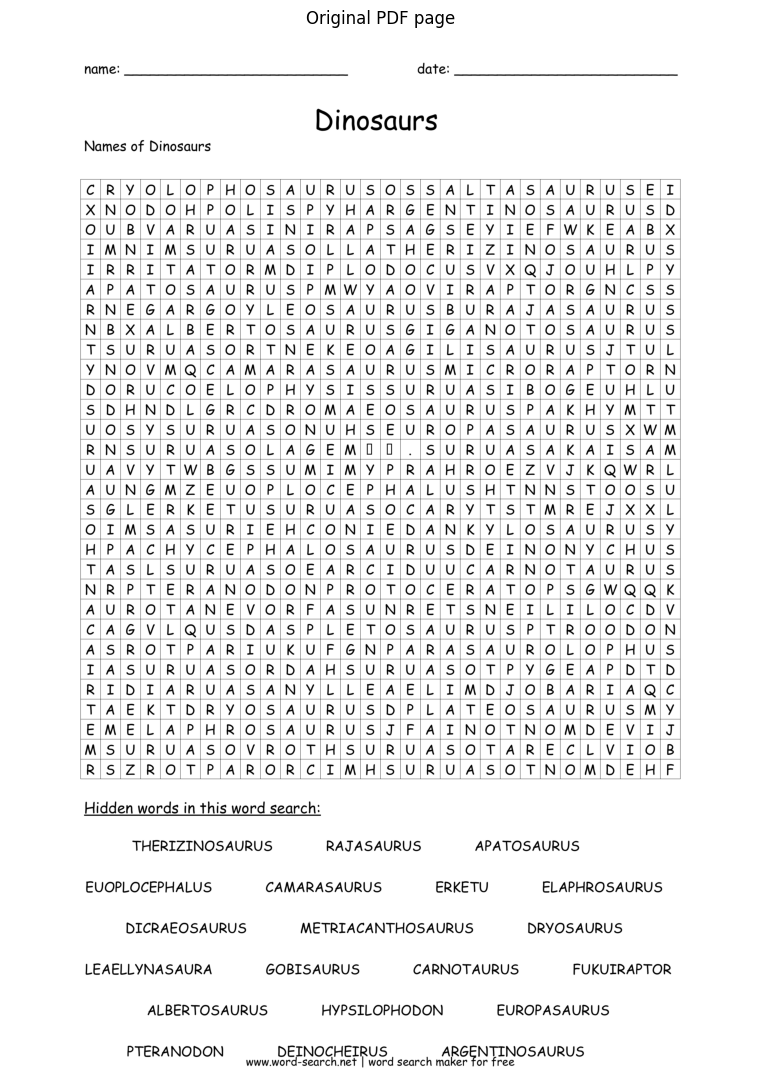

In [4]:
# ── CELL 4 · PDF → high-res Image ────────────────────────────────────────────
images = convert_from_path(FILE_PATH, first_page=1, last_page=1, dpi=300)
img_pil = images[0]

image_path = '/content/puzzle.png'
img_pil.save(image_path, 'PNG')

img = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
print(f'Image shape: {img.shape}  (height x width x channels)')

plt.figure(figsize=(8, 11))
plt.imshow(img_pil)
plt.title('Original PDF page')
plt.axis('off')
plt.tight_layout()
plt.show()

Grid bounding box : (231,491) → (2251,2509)
Cropped grid shape: (2018, 2020, 3)


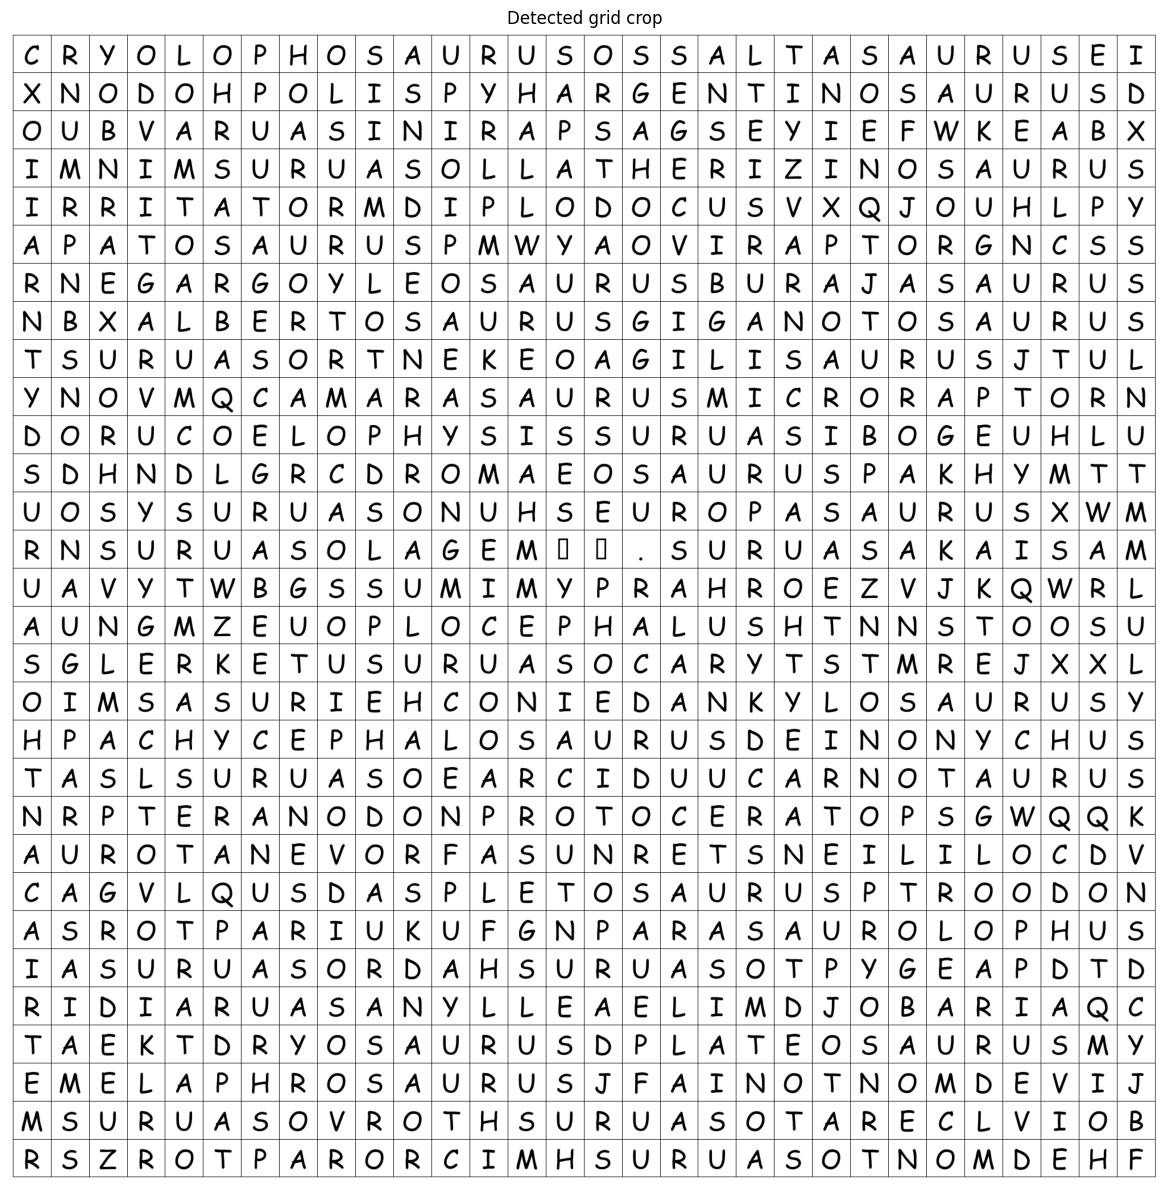

In [5]:
# ── CELL 5 · Grid Detection & Crop ───────────────────────────────────────────
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Adaptive threshold to find grid lines
thresh = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY_INV,
    15, 2
)

h, w = thresh.shape

# Detect horizontal lines
h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(20, w // 20), 1))
horizontal = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, h_kernel)

# Detect vertical lines
v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(20, h // 20)))
vertical = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, v_kernel)

grid_mask = cv2.bitwise_or(horizontal, vertical)

# Find largest contour = the puzzle grid
contours, _ = cv2.findContours(grid_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if not contours:
    raise RuntimeError('No grid contour found — try adjusting kernel sizes.')

largest = max(contours, key=cv2.contourArea)
x, y, bw, bh = cv2.boundingRect(largest)

pad = 5
x1 = max(0, x - pad);  y1 = max(0, y - pad)
x2 = min(w, x + bw + pad); y2 = min(h, y + bh + pad)

grid_crop = img[y1:y2, x1:x2]
print(f'Grid bounding box : ({x1},{y1}) → ({x2},{y2})')
print(f'Cropped grid shape: {grid_crop.shape}')

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(grid_crop, cv2.COLOR_BGR2RGB))
plt.title('Detected grid crop')
plt.axis('off')
plt.tight_layout()
plt.show()

Detected grid: 30 rows × 30 cols


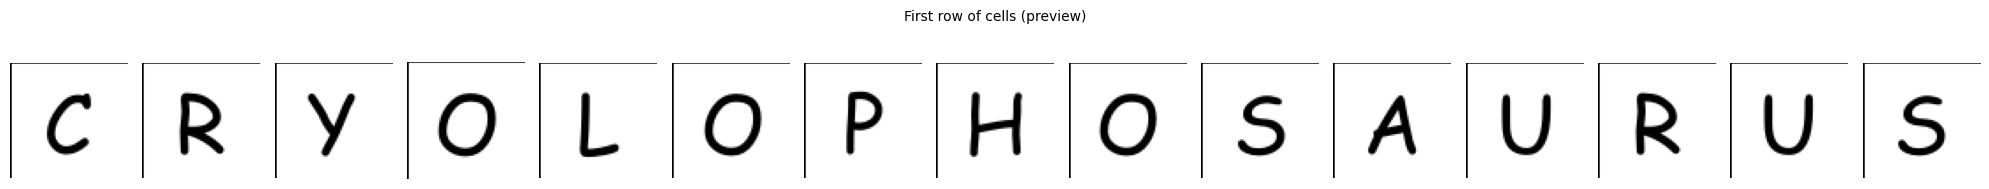

In [6]:
# ── CELL 6 · Cell Segmentation ───────────────────────────────────────────────

grid_gray = cv2.cvtColor(grid_crop, cv2.COLOR_BGR2GRAY)
_, grid_thresh = cv2.threshold(grid_gray, 180, 255, cv2.THRESH_BINARY_INV)

gh, gw = grid_thresh.shape

h_kern = cv2.getStructuringElement(cv2.MORPH_RECT, (gw // 15, 1))
horiz  = cv2.morphologyEx(grid_thresh, cv2.MORPH_OPEN, h_kern)

v_kern = cv2.getStructuringElement(cv2.MORPH_RECT, (1, gh // 15))
vert   = cv2.morphologyEx(grid_thresh, cv2.MORPH_OPEN, v_kern)

contours_h, _ = cv2.findContours(horiz, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_v, _ = cv2.findContours(vert,  cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

rows_pos = sorted(set([cv2.boundingRect(c)[1] for c in contours_h]))
cols_pos = sorted(set([cv2.boundingRect(c)[0] for c in contours_v]))

n_rows = len(rows_pos) - 1
n_cols = len(cols_pos) - 1
print(f'Detected grid: {n_rows} rows × {n_cols} cols')

# Extract individual cell images (grayscale)
cells = []
for i in range(n_rows):
    row_cells = []
    for j in range(n_cols):
        cell = grid_gray[rows_pos[i]:rows_pos[i+1],
                         cols_pos[j]:cols_pos[j+1]]
        row_cells.append(cell)
    cells.append(row_cells)

# Quick sanity preview — first row of cells
fig, axes = plt.subplots(1, min(n_cols, 15), figsize=(20, 2))
for j, ax in enumerate(axes):
    ax.imshow(cells[0][j], cmap='gray')
    ax.axis('off')
plt.suptitle('First row of cells (preview)', fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
# ── CELL 7 · EasyOCR Initialisation ──────────────────────────────────────────
print('Initialising EasyOCR reader (downloads model on first run)...')
reader = easyocr.Reader(['en'], gpu=False, verbose=False)
print('EasyOCR ready.')

Initialising EasyOCR reader (downloads model on first run)...


EasyOCR ready.


In [8]:
# ── CELL 8 · OCR each cell with EasyOCR ──────────────────────────────────────

LETTERS = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'

def preprocess_cell(cell_gray):
    """Crop borders, upscale, enhance contrast, binarise."""
    ch, cw = cell_gray.shape
    # Remove grid-line border (≈10% each side)
    mh = max(3, ch // 10)
    mw = max(3, cw // 10)
    cell = cell_gray[mh:ch - mh, mw:cw - mw]

    # Upscale — EasyOCR works best on ≥32 px tall images
    cell = cv2.resize(cell, (96, 96), interpolation=cv2.INTER_CUBIC)

    # CLAHE — boosts local contrast without blowing out highlights
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
    cell  = clahe.apply(cell)

    # Otsu binarisation
    _, cell = cv2.threshold(cell, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Make sure text is dark on white (EasyOCR expectation)
    if cell.mean() < 128:
        cell = cv2.bitwise_not(cell)

    # Add small white padding so EasyOCR doesn't clip edge pixels
    cell = cv2.copyMakeBorder(cell, 10, 10, 10, 10,
                              cv2.BORDER_CONSTANT, value=255)

    # EasyOCR needs a 3-channel image
    return cv2.cvtColor(cell, cv2.COLOR_GRAY2BGR)


def ocr_cell(cell_img):
    """Run EasyOCR and return the best single uppercase letter."""
    results = reader.readtext(
        cell_img,
        allowlist=LETTERS,
        detail=1,
        paragraph=False,
        # Batch-size 1 avoids RAM spikes on large grids
        batch_size=1
    )

    if not results:
        return '?'

    # Pick the result with the highest confidence
    best = max(results, key=lambda r: r[2])
    text = best[1].strip().upper()

    # Keep only the first valid letter
    for ch in text:
        if ch in LETTERS:
            return ch
    return '?'


# ── Run OCR on every cell ────────────────────────────────────────────────────
print(f'Running EasyOCR on {n_rows}×{n_cols} = {n_rows * n_cols} cells...')

grid_letters = []
for i in range(n_rows):
    row = []
    for j in range(n_cols):
        processed = preprocess_cell(cells[i][j])
        letter    = ocr_cell(processed)
        row.append(letter)

    grid_letters.append(row)

    # Progress every 5 rows
    if (i + 1) % 5 == 0 or i == n_rows - 1:
        print(f'  Row {i+1:2d}/{n_rows} done')

print('\nRAW OCR GRID:')
for i, row in enumerate(grid_letters):
    print(f'  {i:2d}: {" ".join(row)}')

Running EasyOCR on 30×30 = 900 cells...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Row  5/30 done
  Row 10/30 done
  Row 15/30 done
  Row 20/30 done
  Row 25/30 done
  Row 30/30 done

RAW OCR GRID:
   0: C R ? O L O P H O S A U R U S O S S A L T A S A U R U S E I
   1: ? N O D O H P O L I S P ? H A R G E N T I N O S A U R U S D
   2: O U B ? A R U A S I N I R A P S A G S E ? I E F W K E A B ?
   3: I M N I M S U R U A S O L L A T H E R I ? I N O S A U R U S
   4: I R R I T A T O R M D I P L O D O C U S ? ? ? J O U H L P ?
   5: A P A T O S A U R U S P M W ? A O ? I R A P T O R G N C S S
   6: R N E G A R G O ? L E O S A U R U S B U R A J A S A U R U S
   7: N B ? A L B E R T O S A U R U S G I G A N O T O S A U R U S
   8: T S U R U A S O R T N E K E O A G I L I S A U R U S J T U L
   9: ? N O ? M ? C A M A R A S A U R U S M I C R O R A P T O R N
  10: D O R U C O E L O P H ? S I S S U R U A S I B O G E U H L U
  11: S D H N D L G R C D R O M A E O S A U R U S P A K H ? M T T
  12: U O S ? S U R U A S O N U H S E U R O P A S A U R U S ? W M
  13: R N S U R U A S O L

In [9]:
# ── CELL 9 · Manual corrections (optional) ───────────────────────────────────

corrections = {
    # (row, col): 'LETTER'
    # e.g.  (0, 4): 'L',
}

for (r, c), letter in corrections.items():
    print(f'  Correcting ({r},{c}): {grid_letters[r][c]} → {letter}')
    grid_letters[r][c] = letter

print(f'Applied {len(corrections)} manual correction(s).')

Applied 0 manual correction(s).


In [10]:
# ── CELL 10 · Build clean grid ───────────────────────────────────────────────

def normalise(ch):
    """Minimal normalisation — only obvious numeric/symbol OCR errors."""
    ch = ch.strip().upper()
    mapping = {'0': 'O', '1': 'I', '5': 'S', '8': 'B', '2': 'Z',
               '6': 'G', '7': 'T', '|': 'I', 'l': 'I'}
    if ch in mapping:
        return mapping[ch]
    if ch and ch[0] in 'ABCDEFGHIJKLMNOPQRSTUVWXYZ':
        return ch[0]
    return '?'


clean_grid = [[normalise(ch) for ch in row] for row in grid_letters]

n_rows = len(clean_grid)
n_cols = len(clean_grid[0])
unknown = sum(1 for row in clean_grid for ch in row if ch == '?')
total   = n_rows * n_cols

print(f'Grid size : {n_rows} × {n_cols}')
print(f'Unknown ? : {unknown}/{total} cells ({100*unknown/total:.1f}%)')
print()
print('CLEAN GRID:')
for i, row in enumerate(clean_grid):
    print(f'  {i:2d}: {" ".join(row)}')

Grid size : 30 × 30
Unknown ? : 52/900 cells (5.8%)

CLEAN GRID:
   0: C R ? O L O P H O S A U R U S O S S A L T A S A U R U S E I
   1: ? N O D O H P O L I S P ? H A R G E N T I N O S A U R U S D
   2: O U B ? A R U A S I N I R A P S A G S E ? I E F W K E A B ?
   3: I M N I M S U R U A S O L L A T H E R I ? I N O S A U R U S
   4: I R R I T A T O R M D I P L O D O C U S ? ? ? J O U H L P ?
   5: A P A T O S A U R U S P M W ? A O ? I R A P T O R G N C S S
   6: R N E G A R G O ? L E O S A U R U S B U R A J A S A U R U S
   7: N B ? A L B E R T O S A U R U S G I G A N O T O S A U R U S
   8: T S U R U A S O R T N E K E O A G I L I S A U R U S J T U L
   9: ? N O ? M ? C A M A R A S A U R U S M I C R O R A P T O R N
  10: D O R U C O E L O P H ? S I S S U R U A S I B O G E U H L U
  11: S D H N D L G R C D R O M A E O S A U R U S P A K H ? M T T
  12: U O S ? S U R U A S O N U H S E U R O P A S A U R U S ? W M
  13: R N S U R U A S O L A G E M U U ? S U R U A S A K A I S A M
  14: U A ?

In [11]:
# ── CELL 11 · Word-search solver ─────────────────────────────────────────────

DIRECTIONS = [
    ( 0,  1, '→'),  ( 0, -1, '←'),
    ( 1,  0, '↓'),  (-1,  0, '↑'),
    ( 1,  1, '↘'),  (-1, -1, '↖'),
    ( 1, -1, '↙'),  (-1,  1, '↗'),
]

def find_word(grid, word):
    """Strict exact match (no fuzzy). '?' cells are treated as wildcards."""
    word = word.upper().replace('-', '').replace(' ', '')
    R, C  = len(grid), len(grid[0])
    wlen  = len(word)

    for r in range(R):
        for c in range(C):
            gc = grid[r][c]
            if gc != word[0] and gc != '?':
                continue

            for dr, dc, label in DIRECTIONS:
                path = [(r, c)]
                rr, cc = r, c
                ok = True

                for k in range(1, wlen):
                    rr += dr;  cc += dc
                    if not (0 <= rr < R and 0 <= cc < C):
                        ok = False; break
                    cell_ch = grid[rr][cc]
                    # '?' wildcard matches anything
                    if cell_ch != word[k] and cell_ch != '?':
                        ok = False; break
                    path.append((rr, cc))

                if ok and len(path) == wlen:
                    return path, label

    return None, None


found_words = {}   # word → path
not_found   = []

print('=' * 65)
print(' WORD SEARCH RESULTS')
print('=' * 65)

for w in WORDS:
    path, direction = find_word(clean_grid, w)
    if path:
        found_words[w] = path
        r0, c0 = path[0]
        found_letters = ''.join(clean_grid[r][c] for r, c in path)
        print(f'  ✓  {w:<28} {direction}  ({r0},{c0})   [{found_letters}]')
    else:
        not_found.append(w)
        print(f'  ✗  {w}')

print('=' * 65)
print(f'Found {len(found_words)}/{len(WORDS)} words')
if not_found:
    print(f'\nStill missing: {chr(10).join("  " + w for w in not_found)}')

 WORD SEARCH RESULTS
  ✓  THERIZINOSAURUS              →  (3,15)   [THERI?INOSAURUS]
  ✓  RAJASAURUS                   →  (6,20)   [RAJASAURUS]
  ✓  APATOSAURUS                  →  (5,0)   [APATOSAURUS]
  ✓  EUOPLOCEPHALUS               →  (15,6)   [EUOPLOCEPHALUS]
  ✓  CAMARASAURUS                 →  (9,6)   [CAMARASAURUS]
  ✓  ERKETU                       →  (16,3)   [ERKETU]
  ✓  ELAPHROSAURUS                →  (27,2)   [ELAPHROSAURUS]
  ✓  DICRAEOSAURUS                ←  (19,16)   [DICRAEOSAURUS]
  ✓  METRIACANTHOSAURUS           ↑  (28,0)   [METRIACANTHOSAURUS]
  ✓  DRYOSAURUS                   →  (26,5)   [DR?OSAURUS]
  ✓  LEAELLYNASAURA               ←  (25,17)   [LEAELL?NASAURA]
  ✓  GOBISAURUS                   ←  (10,24)   [GOBISAURUS]
  ✓  CARNOTAURUS                  →  (19,19)   [CARNOTAURUS]
  ✓  FUKUIRAPTOR                  ←  (23,12)   [FUKUIRAPTOR]
  ✓  ALBERTOSAURUS                →  (7,3)   [ALBERTOSAURUS]
  ✓  HYPSILOPHODON                ←  (1,13)   [H?PSILOPHODON]

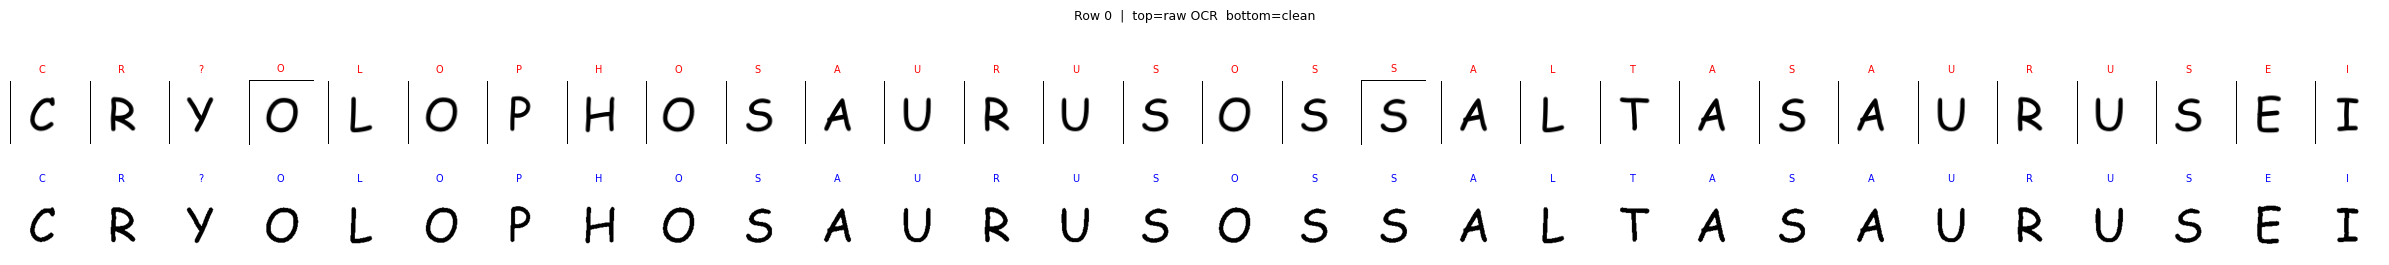

In [13]:
# ── CELL 13 · Debug helper — preview specific cells ───────────────────────────

def show_cell_row(row_idx):
    """Display all raw + preprocessed cells from a given row."""
    fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 0.8, 3))
    for j in range(n_cols):
        raw = cells[row_idx][j]
        proc = preprocess_cell(raw)

        axes[0, j].imshow(raw, cmap='gray')
        axes[0, j].set_title(grid_letters[row_idx][j], fontsize=7, color='red')
        axes[0, j].axis('off')

        axes[1, j].imshow(cv2.cvtColor(proc, cv2.COLOR_BGR2GRAY), cmap='gray')
        axes[1, j].set_title(clean_grid[row_idx][j], fontsize=7, color='blue')
        axes[1, j].axis('off')

    plt.suptitle(f'Row {row_idx}  |  top=raw OCR  bottom=clean', fontsize=9)
    plt.tight_layout()
    plt.show()


# Example: inspect row 0
show_cell_row(0)

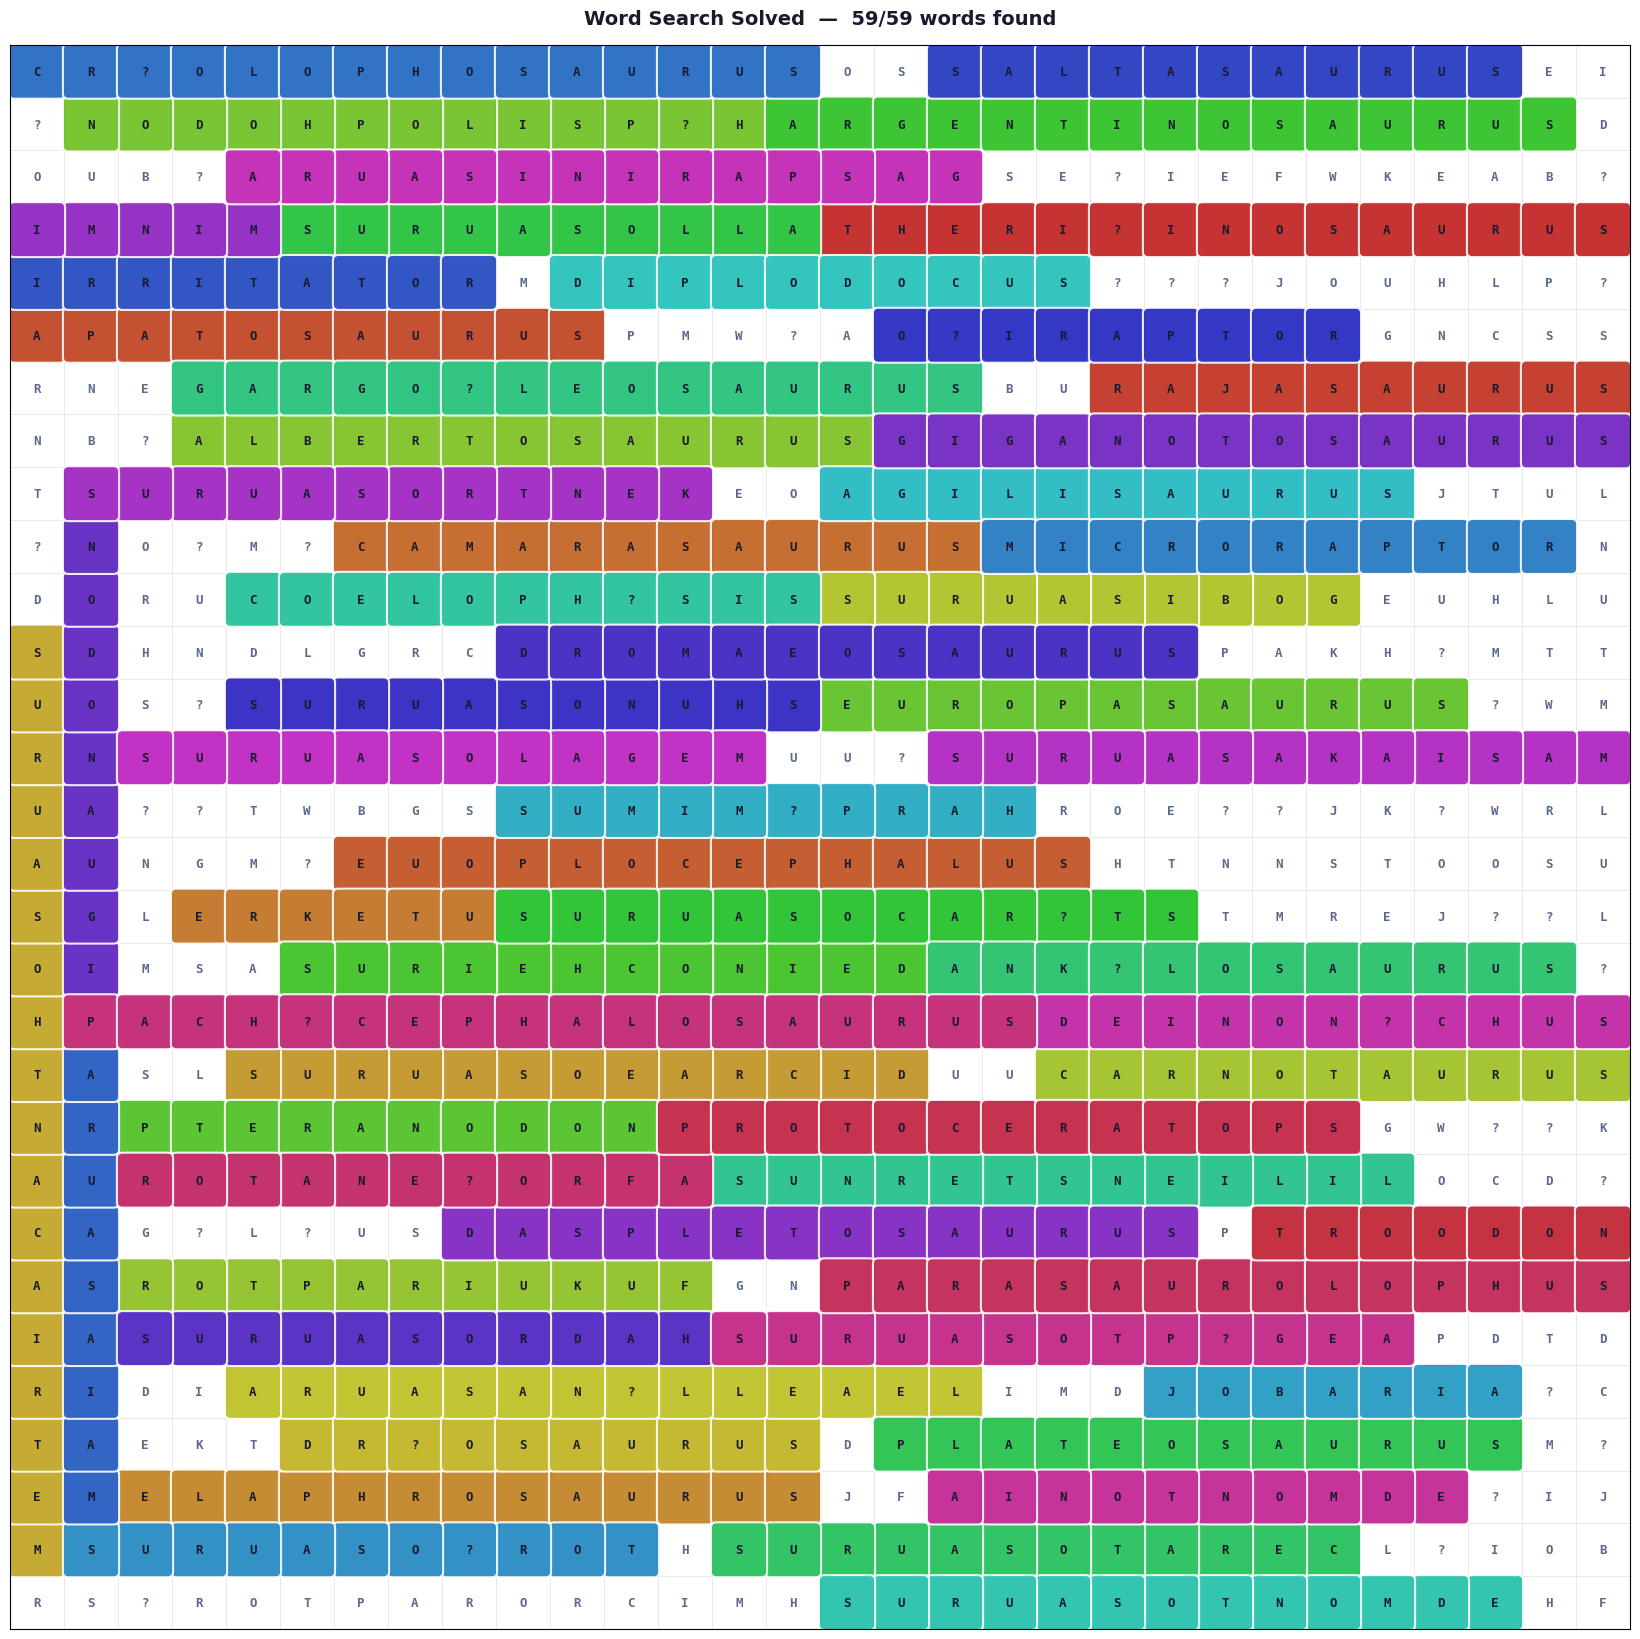

Saved → /content/wordsearch_solved1.png


In [14]:
# ── CELL 12 · Visualisation (White Background Version) ─────────────────────────

def plot_solution(grid, found, all_words):
    R, C = len(grid), len(grid[0])
    n_found = len(found)

    fig, ax = plt.subplots(figsize=(max(14, C * 0.55), max(14, R * 0.55)))
    ax.set_xlim(0, C); ax.set_ylim(0, R)
    ax.invert_yaxis()

    # White/light background
    ax.set_facecolor('#ffffff')
    fig.patch.set_facecolor('#ffffff')

    # Assign distinct, vibrant colours to every found word
    word_colour = {}
    for idx, word in enumerate(found):
        hue = idx / max(n_found, 1)
        # Use more saturated, vibrant colors that stand out on white
        word_colour[word] = hsv_to_rgb([hue, 0.85, 0.75])

    # Map cell → colour (last word wins for overlapping cells)
    cell_colour = {}
    for word, path in found.items():
        for (r, c) in path:
            cell_colour[(r, c)] = word_colour[word]

    # Draw highlighted cells first (with softer edges)
    for (r, c), colour in cell_colour.items():
        rect = patches.FancyBboxPatch(
            (c + 0.08, r + 0.08), 0.84, 0.84,
            boxstyle='round,pad=0.1',
            facecolor=colour, alpha=0.90,
            edgecolor='white', linewidth=1.5, zorder=2
        )
        ax.add_patch(rect)

    # Draw every letter
    for r in range(R):
        for c in range(C):
            ch     = grid[r][c]
            is_hit = (r, c) in cell_colour

            ax.text(c + 0.5, r + 0.5, ch,
                    ha='center', va='center',
                    fontsize=9,
                    fontweight='bold',
                    color='#1a1a2e' if is_hit else '#5a6a8a',  # Dark text for visibility
                    fontfamily='monospace', zorder=3)

    # Subtle grid lines (light gray)
    for i in range(R + 1):
        ax.axhline(i, color='#e0e0e0', linewidth=0.5, zorder=1)
    for j in range(C + 1):
        ax.axvline(j, color='#e0e0e0', linewidth=0.5, zorder=1)

    ax.set_xticks([]); ax.set_yticks([])

    # Title with dark text for white background
    title = (f'Word Search Solved  —  {n_found}/{len(all_words)} words found')
    ax.set_title(title, fontsize=14, fontweight='bold',
                 color='#1a1a2e', pad=15)

    plt.tight_layout()
    out_path = '/content/wordsearch_solved.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Saved → {out_path}')


plot_solution(clean_grid, found_words, WORDS)